In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [2]:
priority = pd.read_csv(
    "../data/processed/search_priority_scores.csv"
)

feature_importance = pd.read_csv(
    "../data/processed/location_feature_importance.csv"
)

print("Priority data:", priority.shape)
print("Feature importance:", feature_importance.shape)

Priority data: (7, 10)
Feature importance: (22, 2)


In [3]:
priority = pd.read_csv(
    "../data/processed/search_priority_scores.csv"
)

feature_importance = pd.read_csv(
    "../data/processed/location_feature_importance.csv"
)

print("Priority data:", priority.shape)
print("Feature importance:", feature_importance.shape)

Priority data: (7, 10)
Feature importance: (22, 2)


In [4]:
priority.head(5)

,Rank,Area,ML_Score,Historical_Score,Route_Score,Distance_Score,Time_Score,Anomaly_Score,Priority_Score,Priority
0,1,9,100.0,100.00,0.0,99.90,100.00,0.14,75.00,High
1,2,1,0.0,37.47,0.0,99.87,48.16,0.42,27.33,Low
2,3,0,0.0,5.36,0.0,96.99,7.01,5.77,16.90,Low
3,4,6,0.0,4.67,0.0,98.30,4.49,4.07,16.54,Low
4,5,2,0.0,7.92,0.0,88.23,8.01,6.52,16.27,Low


In [5]:
top_area = priority.iloc[0]

print(
    "Highest Priority Area:",
    top_area["Area"]
)

print(
    "Priority Score:",
    top_area["Priority_Score"]
)

print(
    "Priority Level:",
    top_area["Priority"]
)

Highest Priority Area: 9
Priority Score: 75.0
Priority Level: High


In [6]:
score_columns = [
    "ML_Score",
    "Historical_Score",
    "Route_Score",
    "Distance_Score",
    "Time_Score",
    "Anomaly_Score"
]

top_area_scores = top_area[
    score_columns
]

top_area_scores

ML_Score            100.0
Historical_Score    100.0
Route_Score           0.0
Distance_Score       99.9
Time_Score          100.0
Anomaly_Score        0.14
Name: 0, dtype: object

In [7]:
contributions = pd.DataFrame({
    "Factor": [
        "ML Prediction",
        "Historical Frequency",
        "Route Similarity",
        "Distance Relevance",
        "Time Relevance",
        "Anomaly Evidence"
    ],
    
    "Score": [
        top_area["ML_Score"],
        top_area["Historical_Score"],
        top_area["Route_Score"],
        top_area["Distance_Score"],
        top_area["Time_Score"],
        top_area["Anomaly_Score"]
    ],
    
    "Weight": [
        0.30,
        0.20,
        0.15,
        0.15,
        0.10,
        0.10
    ]
})

In [8]:
contributions["Weighted_Contribution"] = (
    contributions["Score"]
    *
    contributions["Weight"]
)

contributions

,Factor,Score,Weight,Weighted_Contribution
0,ML Prediction,100.00,0.30,30.000
1,Historical Frequency,100.00,0.20,20.000
2,Route Similarity,0.00,0.15,0.000
3,Distance Relevance,99.90,0.15,14.985
4,Time Relevance,100.00,0.10,10.000
5,Anomaly Evidence,0.14,0.10,0.014


In [9]:
contributions = contributions.sort_values(
    "Weighted_Contribution",
    ascending=False
)

contributions

,Factor,Score,Weight,Weighted_Contribution
0,ML Prediction,100.00,0.30,30.000
1,Historical Frequency,100.00,0.20,20.000
3,Distance Relevance,99.90,0.15,14.985
4,Time Relevance,100.00,0.10,10.000
5,Anomaly Evidence,0.14,0.10,0.014
2,Route Similarity,0.00,0.15,0.000


In [10]:
contributions = contributions.sort_values(
    "Weighted_Contribution",
    ascending=False
)

contributions

,Factor,Score,Weight,Weighted_Contribution
0,ML Prediction,100.00,0.30,30.000
1,Historical Frequency,100.00,0.20,20.000
3,Distance Relevance,99.90,0.15,14.985
4,Time Relevance,100.00,0.10,10.000
5,Anomaly Evidence,0.14,0.10,0.014
2,Route Similarity,0.00,0.15,0.000


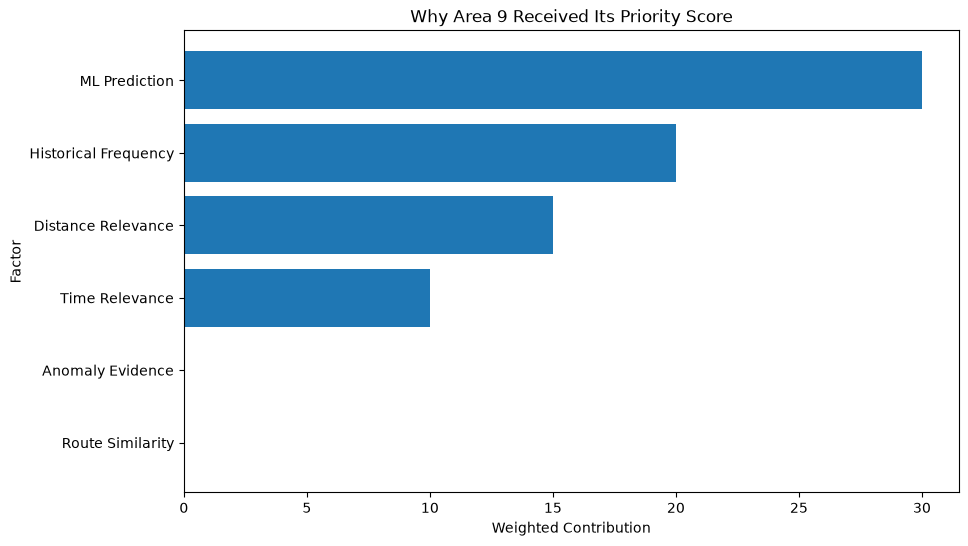

In [11]:
plt.figure(figsize=(10, 6))

plt.barh(
    contributions["Factor"],
    contributions["Weighted_Contribution"]
)

plt.xlabel("Weighted Contribution")
plt.ylabel("Factor")

plt.title(
    f"Why Area {top_area['Area']} Received Its Priority Score"
)

plt.gca().invert_yaxis()

plt.show()

In [12]:
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Previous_Area,0.282705
1,Usual_Area,0.251168
2,Last_Latitude,0.215328
3,Average_Distance,0.053935
4,Last_Longitude,0.053421
5,Average_Speed,0.042071
6,Hour,0.018008
7,Time_Since_Last_Seen,0.012602
8,Day_Wednesday,0.011372
9,Weather_Cloudy,0.009517


In [13]:
top_ml_features = feature_importance.head(10)

for _, row in top_ml_features.iterrows():
    
    print(
        row["Feature"],
        "→",
        round(row["Importance"], 4)
    )

Previous_Area → 0.2827
Usual_Area → 0.2512
Last_Latitude → 0.2153
Average_Distance → 0.0539
Last_Longitude → 0.0534
Average_Speed → 0.0421
Hour → 0.018
Time_Since_Last_Seen → 0.0126
Day_Wednesday → 0.0114
Weather_Cloudy → 0.0095


In [14]:
explanations = []

if top_area["Historical_Score"] >= 70:
    explanations.append(
        "The area has a high historical visit frequency."
    )

if top_area["Route_Score"] >= 50:
    explanations.append(
        "The area is strongly supported by historical route transitions."
    )

if top_area["Distance_Score"] >= 70:
    explanations.append(
        "The area's distance is consistent with the historical movement range."
    )

if top_area["Time_Score"] >= 70:
    explanations.append(
        "The current time is strongly associated with historical visits to this area."
    )

if top_area["ML_Score"] >= 50:
    explanations.append(
        "The location prediction model assigns a relatively high probability to this area."
    )

if top_area["Anomaly_Score"] >= 50:
    explanations.append(
        "The area contains statistically unusual movement observations."
    )

if len(explanations) == 0:
    explanations.append(
        "The area received its ranking from a combination of the available movement and contextual factors."
    )

for i, explanation in enumerate(
    explanations,
    start=1
):
    print(
        f"{i}. {explanation}"
    )

1. The area has a high historical visit frequency.
2. The area's distance is consistent with the historical movement range.
3. The current time is strongly associated with historical visits to this area.
4. The location prediction model assigns a relatively high probability to this area.


In [15]:
xai_report = {
    "Area": top_area["Area"],
    "Priority_Score": top_area["Priority_Score"],
    "Priority": top_area["Priority"],
    "ML_Score": top_area["ML_Score"],
    "Historical_Score": top_area["Historical_Score"],
    "Route_Score": top_area["Route_Score"],
    "Distance_Score": top_area["Distance_Score"],
    "Time_Score": top_area["Time_Score"],
    "Anomaly_Score": top_area["Anomaly_Score"],
    "Explanation": " ".join(explanations)
}

xai_report

{'Area': np.int64(9),
 'Priority_Score': np.float64(75.0),
 'Priority': 'High',
 'ML_Score': np.float64(100.0),
 'Historical_Score': np.float64(100.0),
 'Route_Score': np.float64(0.0),
 'Distance_Score': np.float64(99.9),
 'Time_Score': np.float64(100.0),
 'Anomaly_Score': np.float64(0.14),
 'Explanation': "The area has a high historical visit frequency. The area's distance is consistent with the historical movement range. The current time is strongly associated with historical visits to this area. The location prediction model assigns a relatively high probability to this area."}

In [16]:
xai_df = pd.DataFrame(
    [xai_report]
)

xai_df

,Area,Priority_Score,Priority,ML_Score,Historical_Score,Route_Score,Distance_Score,Time_Score,Anomaly_Score,Explanation
0,9,75.0,High,100.0,100.0,0.0,99.9,100.0,0.14,The area has a high historical visit frequency...


In [17]:
xai_df.to_csv(
    "../data/processed/xai_explanation.csv",
    index=False
)

print(
    "XAI explanation saved successfully!"
)

XAI explanation saved successfully!


In [18]:
contributions.to_csv(
    "../data/processed/xai_factor_contributions.csv",
    index=False
)

print(
    "XAI factor contributions saved!"
)

XAI factor contributions saved!


In [19]:
print("========== EXPLAINABLE AI ==========")

print(
    "Area:",
    top_area["Area"]
)

print(
    "Priority Score:",
    top_area["Priority_Score"]
)

print(
    "Priority:",
    top_area["Priority"]
)

print("\nWhy this area ranked highly:")

for explanation in explanations:
    print(
        "•",
        explanation
    )

========== EXPLAINABLE AI ==========
Area: 9
Priority Score: 75.0
Priority: High

Why this area ranked highly:
• The area has a high historical visit frequency.
• The area's distance is consistent with the historical movement range.
• The current time is strongly associated with historical visits to this area.
• The location prediction model assigns a relatively high probability to this area.


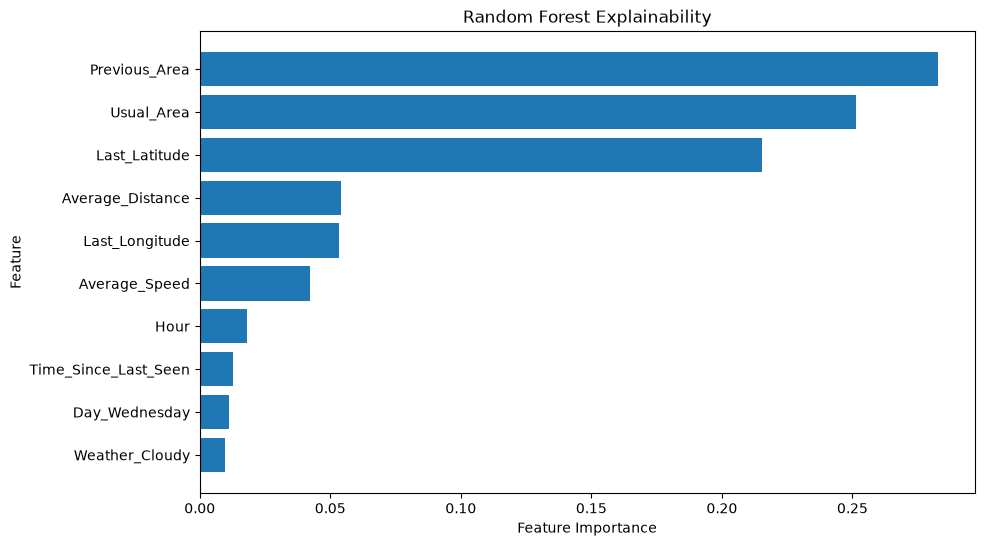

In [20]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Random Forest Explainability"
)

plt.gca().invert_yaxis()

plt.show()

In [21]:
print(
    "XAI files created:"
)

print(
    "../data/processed/xai_explanation.csv"
)

print(
    "../data/processed/xai_factor_contributions.csv"
)

XAI files created:
../data/processed/xai_explanation.csv
../data/processed/xai_factor_contributions.csv
